# Privacy-Aware Soft Routing (PASR) for Federated RAG

Tests whether **soft routing** (learned per-query fusion weights over 4 retrieval paradigms) keeps
retrieval quality when a **per-silo privacy budget** is enforced across 4 BEIR silos.

**Hypotheses**
- H1: PASR matches CASR (no-privacy soft routing) nDCG@10 within 1.0 point (0.01 on the 0-1 scale)
- H2: PASR reduces privacy-budget overruns by >90% vs. Static Privacy routing
- H3: PASR latency overhead vs. CASR < 100 ms (P95)

**Design notes (read before interpreting results)**
1. Each query is answered by its *own* silo. A retrieval access to a silo's privileged index costs
   `0.01 + U(0.001, 0.01)` epsilon. When the silo's remaining budget drops below 0.05 it is *ineligible*.
2. **Overrun** = an access to a privileged index while the silo is ineligible.
3. **Static Privacy (B4)** is budget-unaware: it keeps using hybrid retrieval, so it keeps overrunning.
4. **PASR (B6)** soft-fuses while eligible; once ineligible it serves from the public BM25 index and does
   **not** touch the privileged index, so its overruns are 0 *by construction*. H2 therefore tests the
   mechanism, and the interesting result is the nDCG cost (H1) of falling back.
5. Routers are trained on 80% of queries and **all quality metrics are computed on the held-out 20%** only.
   The split and the router training are re-done for each seed (42, 43, 44).
6. Group E (privacy) features are part of the 30-dim vector, but router labels (per-paradigm nDCG) do not
   depend on privacy state, so the trained trees ignore them. Effective router input is the 24 A-D features.
7. Latency = router/fusion compute per query (retrieval rankings are precomputed), not end-to-end retrieval.

All expensive steps are cached in `/content/cache/` so re-running after a disconnect skips finished work.

In [1]:
# CELL 1: Install dependencies
!pip install -q beir rank_bm25 xgboost sentence-transformers pytrec-eval-terrier faiss-cpu datasets
print("Dependencies installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.9/304.9 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 54.4 MB/s eta 0:00:00
Dependencies installed.


In [2]:
# CELL 2: Imports and config
import os, json, time, pickle, random, re, warnings, traceback
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')

try:
    import torch
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
except Exception:
    torch = None
    DEVICE = 'cpu'
print('Device:', DEVICE)

os.makedirs('/content/cache', exist_ok=True)
os.makedirs('/content/figures', exist_ok=True)

SEEDS = [42, 43, 44]
MAX_QUERIES_PER_SILO = 500

SILOS = {'S1': 'scifact', 'S2': 'nfcorpus', 'S3': 'arguana', 'S4': 'fiqa'}
SILO_IDS = list(SILOS.keys())

PARADIGMS = ['P1_bm25', 'P2_dense', 'P3_hybrid', 'P4_rerank']
TOP_K = 100
HYBRID_ALPHA = 0.75
RERANK_SHORTLIST = 20
BM25_K1, BM25_B = 1.2, 0.75
DENSE_MAX_LEN = 256
TAU = 0.05

XGB_PARAMS = dict(n_estimators=150, max_depth=2, learning_rate=0.05, random_state=42)

EPS_TOTAL_DEFAULT = 1.0
EPS_THR = 0.05
EPS_BASE_COST = 0.01
EPS_COST_JITTER = (0.001, 0.01)

DENSE_MODEL_NAME = 'sentence-transformers/all-MiniLM-L6-v2'
RERANK_MODEL_NAME = 'cross-encoder/ms-marco-MiniLM-L-6-v2'
ENCODE_BATCH = 64 if DEVICE == 'cuda' else 16

def set_seed(s):
    """Seed python, numpy and torch (if present) for reproducibility."""
    random.seed(s); np.random.seed(s)
    if torch is not None:
        torch.manual_seed(s)

def cache_path(name):
    """Return the absolute path of a cache file."""
    return f'/content/cache/{name}'

def save_cache(obj, name):
    """Pickle an object into the cache directory."""
    with open(cache_path(name), 'wb') as f:
        pickle.dump(obj, f)

def load_cache(name):
    """Load a pickled object from the cache directory, or None if absent/corrupt."""
    p = cache_path(name)
    if os.path.exists(p):
        try:
            with open(p, 'rb') as f:
                return pickle.load(f)
        except Exception:
            return None
    return None

set_seed(42)
print('Config set. Silos:', SILOS, '| Paradigms:', PARADIGMS)

Device: cuda
Config set. Silos: {'S1': 'scifact', 'S2': 'nfcorpus', 'S3': 'arguana', 'S4': 'fiqa'} | Paradigms: ['P1_bm25', 'P2_dense', 'P3_hybrid', 'P4_rerank']


In [3]:
# CELL 3: Download BEIR datasets (official mirror, HuggingFace fallback)
from beir import util as beir_util

BEIR_URL = "https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/{name}.zip"
DATA_ROOT = "/content/beir_data"
os.makedirs(DATA_ROOT, exist_ok=True)

def download_silo(beir_name):
    """Download a BEIR dataset via the official mirror; on failure rebuild it from the
    HuggingFace 'BeIR/<name>' datasets. Returns the local folder or None if both fail."""
    target = os.path.join(DATA_ROOT, beir_name)
    if os.path.exists(os.path.join(target, 'corpus.jsonl')):
        return target
    try:
        beir_util.download_and_unzip(BEIR_URL.format(name=beir_name), DATA_ROOT)
        if os.path.exists(os.path.join(target, 'corpus.jsonl')):
            print(f'  [{beir_name}] downloaded via official BEIR mirror.')
            return target
    except Exception as e:
        print(f'  [{beir_name}] official mirror failed ({e}); trying HuggingFace fallback...')
    try:
        from datasets import load_dataset
        os.makedirs(os.path.join(target, 'qrels'), exist_ok=True)
        corpus_ds = load_dataset(f'BeIR/{beir_name}', 'corpus', split='corpus')
        queries_ds = load_dataset(f'BeIR/{beir_name}', 'queries', split='queries')
        qrels_ds = load_dataset(f'BeIR/{beir_name}-qrels', split='test')
        with open(os.path.join(target, 'corpus.jsonl'), 'w') as f:
            for r in corpus_ds:
                f.write(json.dumps({'_id': str(r['_id']), 'title': r.get('title', ''), 'text': r.get('text', '')}) + '\n')
        with open(os.path.join(target, 'queries.jsonl'), 'w') as f:
            for r in queries_ds:
                f.write(json.dumps({'_id': str(r['_id']), 'text': r.get('text', '')}) + '\n')
        with open(os.path.join(target, 'qrels', 'test.tsv'), 'w') as f:
            f.write('query-id\tcorpus-id\tscore\n')
            for r in qrels_ds:
                f.write(f"{r['query-id']}\t{r['corpus-id']}\t{r['score']}\n")
        print(f'  [{beir_name}] built from HuggingFace fallback.')
        return target
    except Exception as e2:
        print(f'  [{beir_name}] HuggingFace fallback ALSO failed ({e2}). Silo skipped.')
        traceback.print_exc()
        return None

SILO_PATHS = {}
for sid, name in SILOS.items():
    print(f'Downloading {sid} ({name})...')
    SILO_PATHS[sid] = download_silo(name)

active_silos = [s for s in SILO_IDS if SILO_PATHS[s] is not None]
print('\nActive silos:', active_silos)
if len(active_silos) < 2:
    raise RuntimeError('Fewer than 2 silos available - cannot run a federated experiment. Check network access.')

/content/beir_data/scifact.zip:   0%|          | 0.00/2.69M [00:00<?, ?iB/s]

  [scifact] downloaded via official BEIR mirror.


/content/beir_data/nfcorpus.zip:   0%|          | 0.00/2.34M [00:00<?, ?iB/s]

  [nfcorpus] downloaded via official BEIR mirror.


/content/beir_data/arguana.zip:   0%|          | 0.00/3.60M [00:00<?, ?iB/s]

  [arguana] downloaded via official BEIR mirror.


/content/beir_data/fiqa.zip:   0%|          | 0.00/17.1M [00:00<?, ?iB/s]

  [fiqa] downloaded via official BEIR mirror.

Active silos: ['S1', 'S2', 'S3', 'S4']


In [4]:
# CELL 4: Load datasets as silos, subsample to <= 500 queries each
from beir.datasets.data_loader import GenericDataLoader

RAW = {}   # RAW[sid] = (corpus, queries, qrels)
for sid in list(active_silos):
    try:
        corpus, queries, qrels = GenericDataLoader(data_folder=SILO_PATHS[sid]).load(split='test')
    except Exception as e:
        print(f'  [{sid}] load failed ({e}); skipping silo.')
        continue
    qids = [q for q in queries if q in qrels and len(qrels[q]) > 0]   # skip queries without judgments
    random.Random(42).shuffle(qids)
    qids = qids[:MAX_QUERIES_PER_SILO]
    RAW[sid] = (corpus, {q: queries[q] for q in qids}, {q: qrels[q] for q in qids})
    print(f'  [{sid}] {len(corpus)} docs | {len(qids)} queries (after subsampling)')

active_silos = list(RAW.keys())
print('Silos with usable data:', active_silos)

  0%|          | 0/5183 [00:00<?, ?it/s]

  [S1] 5183 docs | 300 queries (after subsampling)


  0%|          | 0/3633 [00:00<?, ?it/s]

  [S2] 3633 docs | 323 queries (after subsampling)


  0%|          | 0/8674 [00:00<?, ?it/s]

  [S3] 8674 docs | 500 queries (after subsampling)


  0%|          | 0/57638 [00:00<?, ?it/s]

  [S4] 57638 docs | 500 queries (after subsampling)
Silos with usable data: ['S1', 'S2', 'S3', 'S4']


In [5]:
# CELL 5: Build BM25 indices per silo (k1=1.2, b=0.75, English stopwords)
from rank_bm25 import BM25Okapi
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def tokenize(s):
    """Lowercase alphanumeric tokenizer with English stopword removal."""
    return [t for t in re.findall(r'[a-z0-9]+', s.lower()) if t not in ENGLISH_STOP_WORDS]

BM25_INDEX = {}    # sid -> (BM25Okapi, doc_ids)
CORPUS_TEXT = {}   # sid -> {doc_id: 'title. text'}
for sid in active_silos:
    corpus = RAW[sid][0]
    doc_ids = list(corpus.keys())
    CORPUS_TEXT[sid] = {d: (corpus[d].get('title', '') + '. ' + corpus[d].get('text', '')).strip() for d in doc_ids}
    tokenized = [tokenize(CORPUS_TEXT[sid][d]) for d in doc_ids]
    BM25_INDEX[sid] = (BM25Okapi(tokenized, k1=BM25_K1, b=BM25_B), doc_ids)
    print(f'  [{sid}] BM25 index over {len(doc_ids)} docs')

  [S1] BM25 index over 5183 docs
  [S2] BM25 index over 3633 docs
  [S3] BM25 index over 8674 docs
  [S4] BM25 index over 57638 docs


In [6]:
# CELL 6: Dense indices per silo (MiniLM + FAISS inner product on normalized vectors)
import faiss

DENSE_OK = True
try:
    from sentence_transformers import SentenceTransformer
    dense_model = SentenceTransformer(DENSE_MODEL_NAME, device=DEVICE)
    dense_model.max_seq_length = DENSE_MAX_LEN
except Exception as e:
    print('sentence-transformers unavailable (', e, ') -> TF-IDF used as dense proxy.')
    from sklearn.feature_extraction.text import TfidfVectorizer
    DENSE_OK = False

DENSE_INDEX = {}   # sid -> (faiss_index, doc_ids)
TFIDF_VEC = {}     # sid -> fitted vectorizer (fallback mode only)
MODE = 'st' if DENSE_OK else 'tfidf'

def l2norm(x):
    """Row-wise L2 normalisation (zero rows left as zeros)."""
    n = np.linalg.norm(x, axis=1, keepdims=True); n[n == 0] = 1
    return (x / n).astype('float32')

for sid in active_silos:
    doc_ids = BM25_INDEX[sid][1]
    texts = [CORPUS_TEXT[sid][d][:2000] for d in doc_ids]
    emb_path = cache_path(f'dense_emb_{MODE}_{sid}_{len(doc_ids)}.npy')
    if DENSE_OK and os.path.exists(emb_path):
        emb = np.load(emb_path)
        print(f'  [{sid}] cached embeddings {emb.shape}')
    elif DENSE_OK:
        emb = dense_model.encode(texts, batch_size=ENCODE_BATCH, show_progress_bar=True,
                                 convert_to_numpy=True, normalize_embeddings=True).astype('float32')
        np.save(emb_path, emb)
        print(f'  [{sid}] encoded {emb.shape}')
    else:
        TFIDF_VEC[sid] = TfidfVectorizer(max_features=2048).fit(texts)
        emb = l2norm(TFIDF_VEC[sid].transform(texts).toarray().astype('float32'))
        print(f'  [{sid}] tf-idf proxy {emb.shape}')
    idx = faiss.IndexFlatIP(emb.shape[1])
    idx.add(emb)
    DENSE_INDEX[sid] = (idx, doc_ids)
print('Dense indices ready.')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

  [S2] encoded (3633, 384)


Batches:   0%|          | 0/136 [00:00<?, ?it/s]

  [S3] encoded (8674, 384)


Batches:   0%|          | 0/901 [00:00<?, ?it/s]

  [S4] encoded (57638, 384)
Dense indices ready.


In [7]:
# CELL 7: Precompute top-100 rankings for P1..P4 on every silo (cached)
RERANK_OK = True
try:
    from sentence_transformers import CrossEncoder
    reranker = CrossEncoder(RERANK_MODEL_NAME, device=DEVICE, max_length=256)
except Exception as e:
    print('Cross-encoder unavailable (', e, ') -> P4 falls back to the hybrid ranking.')
    RERANK_OK = False

def norm01(x):
    """Min-max normalise a 1-D array to [0, 1]."""
    x = np.asarray(x, dtype='float64')
    return (x - x.min()) / (x.max() - x.min() + 1e-9)

def encode_queries(sid, qtexts):
    """Encode a list of query strings into normalised dense vectors."""
    if DENSE_OK:
        return dense_model.encode(qtexts, batch_size=ENCODE_BATCH, convert_to_numpy=True,
                                  normalize_embeddings=True).astype('float32')
    return l2norm(TFIDF_VEC[sid].transform(qtexts).toarray().astype('float32'))

RANKINGS = load_cache(f'rankings_{MODE}_{int(RERANK_OK)}.pkl') or {}   # RANKINGS[sid][paradigm][qid] = [(doc, score)] desc

for sid in active_silos:
    queries = RAW[sid][1]
    if sid in RANKINGS and set(RANKINGS[sid]['P1_bm25']) == set(queries):
        print(f'  [{sid}] rankings cached, skipping.'); continue
    R = {p: {} for p in PARADIGMS}
    bm25, doc_ids = BM25_INDEX[sid]
    dindex = DENSE_INDEX[sid][0]
    qids = list(queries.keys()); qtexts = [queries[q] for q in qids]
    qvecs = encode_queries(sid, qtexts)
    k = min(TOP_K, dindex.ntotal)
    D, I = dindex.search(qvecs, k)
    print(f'  [{sid}] query vecs {qvecs.shape}, dense hits {I.shape}')
    t0 = time.time()
    for i, qid in enumerate(qids):
        bm_scores = np.asarray(bm25.get_scores(tokenize(qtexts[i])))
        top = np.argsort(-bm_scores)[:TOP_K]
        R['P1_bm25'][qid] = [(doc_ids[j], float(bm_scores[j])) for j in top]
        R['P2_dense'][qid] = [(doc_ids[j], float(D[i][r])) for r, j in enumerate(I[i])]
        bm_n = dict(zip([d for d, _ in R['P1_bm25'][qid]], norm01([s for _, s in R['P1_bm25'][qid]])))
        dn_n = dict(zip([d for d, _ in R['P2_dense'][qid]], norm01([s for _, s in R['P2_dense'][qid]])))
        hyb = {d: HYBRID_ALPHA * dn_n.get(d, 0.0) + (1 - HYBRID_ALPHA) * bm_n.get(d, 0.0) for d in set(bm_n) | set(dn_n)}
        hyb_sorted = sorted(hyb.items(), key=lambda x: -x[1])[:TOP_K]
        R['P3_hybrid'][qid] = hyb_sorted
        if RERANK_OK:
            short = hyb_sorted[:RERANK_SHORTLIST]
            ce = reranker.predict([(qtexts[i], CORPUS_TEXT[sid][d][:1000]) for d, _ in short],
                                  batch_size=32, show_progress_bar=False)
            ce_n = 1.0 + norm01(ce)       # reranked block lives in [1, 2] ...
            reranked = sorted(zip([d for d, _ in short], ce_n), key=lambda x: -x[1])
            tail = [(d, 0.99 * s) for d, s in hyb_sorted[RERANK_SHORTLIST:]]   # ... tail stays below 1 so order is preserved
            R['P4_rerank'][qid] = [(d, float(s)) for d, s in reranked] + tail
        else:
            R['P4_rerank'][qid] = hyb_sorted
        if (i + 1) % 100 == 0:
            print(f'    [{sid}] {i+1}/{len(qids)} queries, {(time.time()-t0)/60:.1f} min')
    RANKINGS[sid] = R
    save_cache(RANKINGS, f'rankings_{MODE}_{int(RERANK_OK)}.pkl')
    print(f'  [{sid}] done and cached.')
print('Rankings ready for:', list(RANKINGS.keys()))

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 90.9MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

  [S1] query vecs (300, 384), dense hits (300, 100)
    [S1] 100/300 queries, 0.1 min
    [S1] 200/300 queries, 0.2 min
    [S1] 300/300 queries, 0.3 min
  [S1] done and cached.
  [S2] query vecs (323, 384), dense hits (323, 100)
    [S2] 100/323 queries, 0.1 min
    [S2] 200/323 queries, 0.2 min
    [S2] 300/323 queries, 0.3 min
  [S2] done and cached.
  [S3] query vecs (500, 384), dense hits (500, 100)
    [S3] 100/500 queries, 0.6 min
    [S3] 200/500 queries, 1.1 min
    [S3] 300/500 queries, 1.7 min
    [S3] 400/500 queries, 2.2 min
    [S3] 500/500 queries, 2.8 min
  [S3] done and cached.
  [S4] query vecs (500, 384), dense hits (500, 100)
    [S4] 100/500 queries, 0.3 min
    [S4] 200/500 queries, 0.6 min
    [S4] 300/500 queries, 1.0 min
    [S4] 400/500 queries, 1.3 min
    [S4] 500/500 queries, 1.6 min
  [S4] done and cached.
Rankings ready for: ['S1', 'S2', 'S3', 'S4']


In [8]:
# CELL 8: Features. Groups A-D (24 dims) are query-static; Group E (6 dims) is live privacy state.
print('Building cross-silo global IDF...')
_df, _N = {}, 0
for sid in active_silos:
    doc_ids = BM25_INDEX[sid][1]
    _N += len(doc_ids)
    for d in doc_ids:
        for t in set(tokenize(CORPUS_TEXT[sid][d])):
            _df[t] = _df.get(t, 0) + 1
GLOBAL_IDF = {t: float(np.log((_N + 1) / (c + 1))) for t, c in _df.items()}
print(f'Global IDF: {_N} docs, {len(GLOBAL_IDF)} terms')

def extract_features_AD(sid, qid, qtext):
    """Return the 24 query-static features (Groups A-D) for one query."""
    words = qtext.split()
    toks = tokenize(qtext)
    f_A = [len(words), len(set(w.lower() for w in words)), qtext.count('?'),
           sum(c.isdigit() for c in qtext), sum(c.isupper() for c in qtext),
           float(np.mean([len(w) for w in words])) if words else 0.0]
    bm25 = BM25_INDEX[sid][0]
    iv = [bm25.idf[t] for t in toks if t in bm25.idf]
    gv = [GLOBAL_IDF[t] for t in toks if t in GLOBAL_IDF]
    f_B = [np.mean(iv) if iv else 0.0, np.std(iv) if iv else 0.0,
           np.mean(gv) if gv else 0.0, np.std(gv) if gv else 0.0]
    bm_l = RANKINGS[sid]['P1_bm25'].get(qid, []); dn_l = RANKINGS[sid]['P2_dense'].get(qid, [])
    def margins(lst):
        s = [x for _, x in lst[:5]]
        if not s: return [0.0] * 4
        return [s[0], s[0] - s[min(4, len(s) - 1)], float(np.mean(s)), float(np.std(s))]
    f_C = margins(bm_l) + margins(dn_l)
    b10 = set(d for d, _ in bm_l[:10]); d10 = set(d for d, _ in dn_l[:10])
    inter, union = len(b10 & d10), len(b10 | d10)
    f_D = [inter, union, float(bool(bm_l and dn_l and bm_l[0][0] == dn_l[0][0])),
           inter / union if union else 0.0,
           float(bool(bm_l) and bm_l[0][0] in d10), float(bool(dn_l) and dn_l[0][0] in b10)]
    return [float(x) for x in f_A + f_B + f_C + f_D]

FEATURES_AD = {}   # sid -> qid -> list of 24 floats
for sid in active_silos:
    FEATURES_AD[sid] = {q: extract_features_AD(sid, q, t) for q, t in RAW[sid][1].items()}
    n_feat = len(next(iter(FEATURES_AD[sid].values())))
    print(f'  [{sid}] {len(FEATURES_AD[sid])} queries x {n_feat} features (+6 privacy dims at run time = 30)')
assert n_feat == 24

Building cross-silo global IDF...
Global IDF: 75128 docs, 113012 terms
  [S1] 300 queries x 24 features (+6 privacy dims at run time = 30)
  [S2] 323 queries x 24 features (+6 privacy dims at run time = 30)
  [S3] 500 queries x 24 features (+6 privacy dims at run time = 30)
  [S4] 500 queries x 24 features (+6 privacy dims at run time = 30)


In [9]:
# CELL 9: Per-paradigm labels and router training (re-run per seed in CELL 12)
import pytrec_eval
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor
try:
    from xgboost import XGBClassifier, XGBRegressor
except Exception as e:
    print('xgboost unavailable (', e, ') -> sklearn GradientBoosting fallback.')
    from sklearn.ensemble import GradientBoostingClassifier as XGBClassifier
    from sklearn.ensemble import GradientBoostingRegressor as XGBRegressor
    XGB_PARAMS = {k: v for k, v in XGB_PARAMS.items()}

def run_dict(lst_by_q, topn=None):
    """Convert {qid: [(doc, score)]} to pytrec_eval's {qid: {doc: score}} (optionally top-n only)."""
    return {q: {d: float(s) for d, s in (lst[:topn] if topn else lst)} for q, lst in lst_by_q.items()}

def per_query_scores(sid, lst_by_q, topn=10, measures=('ndcg_cut.10', 'recall.10', 'recip_rank')):
    """Per-query metrics for one silo. Runs are cut to the top-n so recip_rank is MRR@10."""
    qrels = RAW[sid][2]
    common = [q for q in lst_by_q if q in qrels]
    if not common: return {}
    ev = pytrec_eval.RelevanceEvaluator({q: qrels[q] for q in common}, set(measures))
    return ev.evaluate(run_dict({q: lst_by_q[q] for q in common}, topn))

print('Scoring every paradigm per query (router labels)...')
PARADIGM_NDCG = {sid: {p: {q: v['ndcg_cut_10'] for q, v in per_query_scores(sid, RANKINGS[sid][p]).items()}
                       for p in PARADIGMS} for sid in active_silos}
for sid in active_silos:
    print(f'  [{sid}] mean nDCG@10:', {p.split("_")[0]: round(np.mean(list(PARADIGM_NDCG[sid][p].values())), 3) for p in PARADIGMS})

META = [(sid, q) for sid in active_silos for q in FEATURES_AD[sid]]
X_ALL = np.array([FEATURES_AD[s][q] + [0.0] * 6 for s, q in META])         # Group E placeholder (privacy-independent labels)
Y_SOFT = np.array([[PARADIGM_NDCG[s][p].get(q, 0.0) for p in PARADIGMS] for s, q in META])
Y_HARD = Y_SOFT.argmax(axis=1)
print('X', X_ALL.shape, '| Y_soft', Y_SOFT.shape, '| hard label counts', np.bincount(Y_HARD, minlength=4))

def train_routers(seed):
    """80/20 split (random_state=seed) and train Hard Router (classifier) + CASR (multi-output regressor).
    Returns dict with models and the held-out set of (sid, qid)."""
    set_seed(seed)
    tr, te = train_test_split(np.arange(len(X_ALL)), test_size=0.2, random_state=seed)
    params = dict(XGB_PARAMS); params['random_state'] = seed
    classes = np.unique(Y_HARD[tr])
    y_enc = np.searchsorted(classes, Y_HARD[tr])        # xgboost needs contiguous labels
    hard = XGBClassifier(**params).fit(X_ALL[tr], y_enc)
    casr = MultiOutputRegressor(XGBRegressor(**params)).fit(X_ALL[tr], Y_SOFT[tr])
    acc = float((classes[np.asarray(hard.predict(X_ALL[te])).astype(int)] == Y_HARD[te]).mean())
    r2_like = float(np.mean(np.abs(casr.predict(X_ALL[te]) - Y_SOFT[te])))
    print(f'  seed {seed}: train {len(tr)} / test {len(te)} | hard-router acc {acc:.3f} | CASR MAE {r2_like:.3f}')
    return dict(hard=hard, hard_classes=classes, casr=casr, test_set={META[i] for i in te})

def softmax(x, tau=TAU):
    """Temperature softmax."""
    x = np.asarray(x, dtype='float64'); e = np.exp((x - x.max()) / tau)
    return e / e.sum()

_smoke = train_routers(42)
print('Router smoke test OK.')

Scoring every paradigm per query (router labels)...
  [S1] mean nDCG@10: {'P1': np.float64(0.669), 'P2': np.float64(0.648), 'P3': np.float64(0.688), 'P4': np.float64(0.69)}
  [S2] mean nDCG@10: {'P1': np.float64(0.312), 'P2': np.float64(0.318), 'P3': np.float64(0.335), 'P4': np.float64(0.348)}
  [S3] mean nDCG@10: {'P1': np.float64(0.35), 'P2': np.float64(0.367), 'P3': np.float64(0.377), 'P4': np.float64(0.39)}
  [S4] mean nDCG@10: {'P1': np.float64(0.225), 'P2': np.float64(0.357), 'P3': np.float64(0.383), 'P4': np.float64(0.39)}
X (1623, 30) | Y_soft (1623, 4) | hard label counts [844 377  90 312]
  seed 42: train 1298 / test 325 | hard-router acc 0.538 | CASR MAE 0.247
Router smoke test OK.


In [10]:
# CELL 10: Privacy budget tracker
class PrivacyBudgetTracker:
    """Per-silo epsilon budget. Each access to a silo's privileged index costs
    eps_base + U(jitter). A silo is *eligible* while remaining >= eps_thr.
    An access made while the silo is ineligible is an overrun (cost is still deducted)."""
    def __init__(self, silos, eps_total=EPS_TOTAL_DEFAULT, eps_thr=EPS_THR,
                 eps_base=EPS_BASE_COST, jitter=EPS_COST_JITTER, seed=42):
        self.silos = list(silos); self.eps_total = eps_total; self.eps_thr = eps_thr
        self.eps_base = eps_base; self.jitter = jitter
        self.remaining = {s: float(eps_total) for s in silos}
        self.overruns = {s: 0 for s in silos}
        self.accesses = {s: 0 for s in silos}
        self.rng = random.Random(seed)

    def eligible(self, silo):
        """True if the silo still has at least eps_thr budget left."""
        return self.remaining[silo] >= self.eps_thr

    def access(self, silo):
        """Record one privileged access. Returns True if allowed, False if it was an overrun."""
        cost = self.eps_base + self.rng.uniform(*self.jitter)
        ok = self.eligible(silo)
        self.remaining[silo] = max(0.0, self.remaining[silo] - cost)
        self.accesses[silo] += 1
        if not ok: self.overruns[silo] += 1
        return ok

    def group_e(self):
        """6-dim privacy feature vector: per-silo remaining (4), total remaining, total overruns."""
        rem = [self.remaining.get(s, 0.0) for s in SILO_IDS]
        return rem + [sum(self.remaining.values()), float(sum(self.overruns.values()))]

    def total_overruns(self):
        """Overruns summed over silos."""
        return sum(self.overruns.values())

    def total_remaining(self):
        """Remaining budget summed over silos."""
        return sum(self.remaining.values())

_t = PrivacyBudgetTracker(active_silos, eps_total=0.1)
flags = [_t.access(active_silos[0]) for _ in range(20)]
print(f'Smoke test eps_total=0.1: allowed={sum(flags)}, overruns={_t.overruns[active_silos[0]]}, remaining={_t.remaining[active_silos[0]]:.3f}')

Smoke test eps_total=0.1: allowed=4, overruns=16, remaining=0.000


In [11]:
# CELL 11: Baselines B1-B7. All share the signature fn(sid, qid, tracker) -> ranking list.
CUR = {}   # holds the routers of the seed currently being evaluated (set in CELL 12)

def feats30(sid, qid, tracker=None):
    """30-dim feature row: 24 static + 6 privacy dims (zeros when no tracker)."""
    return np.array(FEATURES_AD[sid][qid] + (tracker.group_e() if tracker is not None else [0.0] * 6)).reshape(1, -1)

def soft_fuse(sid, qid, weights):
    """Weighted score-level fusion of the four paradigm rankings (per-paradigm min-max normalisation)."""
    fused = {}
    for p, w in zip(PARADIGMS, weights):
        lst = RANKINGS[sid][p].get(qid, [])
        if not lst: continue
        for (d, _), s in zip(lst, norm01([x for _, x in lst])):
            fused[d] = fused.get(d, 0.0) + float(w) * s
    return sorted(fused.items(), key=lambda x: -x[1])[:TOP_K]

def b1_fixed_hybrid(sid, qid, tracker=None):
    """B1: always hybrid (P3)."""
    if tracker is not None: tracker.access(sid)
    return RANKINGS[sid]['P3_hybrid'].get(qid, [])

def b2_rrf(sid, qid, tracker=None, k=60):
    """B2: reciprocal rank fusion of BM25 and dense (k=60)."""
    if tracker is not None: tracker.access(sid)
    sc = {}
    for p in ('P1_bm25', 'P2_dense'):
        for r, (d, _) in enumerate(RANKINGS[sid][p].get(qid, []), 1):
            sc[d] = sc.get(d, 0.0) + 1.0 / (k + r)
    return sorted(sc.items(), key=lambda x: -x[1])[:TOP_K]

def b3_hard_router(sid, qid, tracker=None):
    """B3: classifier picks ONE paradigm per query."""
    pred = int(np.asarray(CUR['hard'].predict(feats30(sid, qid))).astype(int)[0])
    if tracker is not None: tracker.access(sid)
    return RANKINGS[sid][PARADIGMS[int(CUR['hard_classes'][pred])]].get(qid, [])

def b4_static_privacy(sid, qid, tracker):
    """B4: budget-UNAWARE static policy - always uses the privileged hybrid index, even when the
    silo is out of budget (so it keeps accumulating overruns)."""
    tracker.access(sid)
    return RANKINGS[sid]['P3_hybrid'].get(qid, [])

def b5_casr(sid, qid, tracker=None):
    """B5: CASR - softmax(tau=0.05) over predicted per-paradigm nDCG, no privacy constraint."""
    w = softmax(CUR['casr'].predict(feats30(sid, qid))[0])
    if tracker is not None: tracker.access(sid)
    return soft_fuse(sid, qid, w)

def b6_pasr(sid, qid, tracker):
    """B6: PASR - CASR soft fusion while the silo is eligible (privacy features fed to the regressor);
    once ineligible it serves the public BM25 ranking and does NOT access the privileged index,
    hence no overrun is logged."""
    if tracker.eligible(sid):
        w = softmax(CUR['casr'].predict(feats30(sid, qid, tracker))[0])
        tracker.access(sid)
        return soft_fuse(sid, qid, w)
    return RANKINGS[sid]['P1_bm25'].get(qid, [])

def b7_oracle(sid, qid, tracker=None):
    """B7: oracle - per-query best paradigm by ground-truth nDCG@10 (upper bound)."""
    sc = [PARADIGM_NDCG[sid][p].get(qid, 0.0) for p in PARADIGMS]
    if tracker is not None: tracker.access(sid)
    return RANKINGS[sid][PARADIGMS[int(np.argmax(sc))]].get(qid, [])

print('Baselines B1-B7 defined.')

Baselines B1-B7 defined.


In [12]:
# CELL 12: Experiment matrix E1-E10 x 3 seeds. Routers retrained per seed; metrics on held-out queries only.
EXPERIMENTS = {
    'E1_FixedHybrid':   dict(fn=b1_fixed_hybrid,   privacy=False),
    'E2_RRF':           dict(fn=b2_rrf,            privacy=False),
    'E3_HardRouter':    dict(fn=b3_hard_router,    privacy=False),
    'E4_CASR':          dict(fn=b5_casr,           privacy=False),
    'E5_StaticPrivacy': dict(fn=b4_static_privacy, privacy=True, eps=1.0),
    'E6_PASR_eps0.1':   dict(fn=b6_pasr,           privacy=True, eps=0.1),
    'E7_PASR_eps0.5':   dict(fn=b6_pasr,           privacy=True, eps=0.5),
    'E8_PASR_eps1.0':   dict(fn=b6_pasr,           privacy=True, eps=1.0),
    'E9_PASR_eps2.0':   dict(fn=b6_pasr,           privacy=True, eps=2.0),
    'E10_Oracle':       dict(fn=b7_oracle,         privacy=False),
}

def evaluate_run(run, test_set):
    """Pooled and per-silo nDCG@10 / Recall@10 / MRR@10 over the held-out (sid, qid) pairs only."""
    pooled = {'ndcg_cut_10': [], 'recall_10': [], 'recip_rank': []}; per_silo = {}
    for sid, lists in run.items():
        held = {q: l for q, l in lists.items() if (sid, q) in test_set}
        res = per_query_scores(sid, held)
        if not res: continue
        for m in pooled: pooled[m] += [v[m] for v in res.values()]
        per_silo[sid] = dict(ndcg10=np.mean([v['ndcg_cut_10'] for v in res.values()]),
                             recall10=np.mean([v['recall_10'] for v in res.values()]),
                             mrr10=np.mean([v['recip_rank'] for v in res.values()]), n=len(res))
    overall = dict(ndcg10=np.mean(pooled['ndcg_cut_10']), recall10=np.mean(pooled['recall_10']),
                   mrr10=np.mean(pooled['recip_rank']), n=len(pooled['ndcg_cut_10']))
    return overall, per_silo

RESULTS_ROWS, PER_SILO_ROWS = [], []
t_start = time.time()
for seed in SEEDS:
    print(f'\n=== Seed {seed}: training routers ===')
    CUR.update(train_routers(seed))
    test_set = CUR['test_set']
    for exp_name, cfg in EXPERIMENTS.items():
        set_seed(seed)
        tracker = PrivacyBudgetTracker(active_silos, eps_total=cfg['eps'], seed=seed) if cfg['privacy'] else None
        run = {sid: {} for sid in active_silos}; lat = []; n_served = 0
        for sid in active_silos:
            qids = list(RAW[sid][1].keys())
            random.Random(seed).shuffle(qids)          # arrival order of traffic differs per seed
            for qid in qids:
                t0 = time.perf_counter()
                try:
                    ranking = cfg['fn'](sid, qid, tracker)
                except Exception as e:
                    print(f'    WARNING {exp_name} {sid}/{qid}: {e}')
                    ranking = RANKINGS[sid]['P3_hybrid'].get(qid, [])
                lat.append((time.perf_counter() - t0) * 1000)
                run[sid][qid] = ranking; n_served += 1
        overall, per_silo = evaluate_run(run, test_set)
        lat = np.array(lat)
        row = dict(experiment=exp_name, seed=seed, ndcg10=overall['ndcg10'], recall10=overall['recall10'],
                   mrr10=overall['mrr10'], n_test_queries=overall['n'], n_served=n_served,
                   lat_mean_ms=lat.mean(), lat_p95_ms=np.percentile(lat, 95), lat_p99_ms=np.percentile(lat, 99))
        if tracker is not None:
            row.update(total_overruns=tracker.total_overruns(),
                       overruns_per_1k=1000.0 * tracker.total_overruns() / n_served,
                       unauthorized_violations=tracker.total_overruns(),   # every overrun is an unauthorised privileged access
                       budget_utilization=1 - tracker.total_remaining() / (tracker.eps_total * len(active_silos)),
                       eligible_silos_end=sum(tracker.eligible(s) for s in active_silos))
        else:
            row.update(total_overruns=0, overruns_per_1k=0.0, unauthorized_violations=0,
                       budget_utilization=np.nan, eligible_silos_end=len(active_silos))
        RESULTS_ROWS.append(row)
        PER_SILO_ROWS += [dict(experiment=exp_name, seed=seed, silo=s, **m) for s, m in per_silo.items()]
        print(f'  {exp_name:17s} nDCG@10={overall["ndcg10"]:.4f} overruns/1k={row["overruns_per_1k"]:7.1f} '
              f'P95={row["lat_p95_ms"]:6.2f}ms [{(time.time()-t_start)/60:.1f} min]')

results_df = pd.DataFrame(RESULTS_ROWS); per_silo_df = pd.DataFrame(PER_SILO_ROWS)
results_df.to_csv('/content/cache/raw_results_by_seed.csv', index=False)
print('\nMatrix complete:', results_df.shape, '| time', round((time.time() - t_start) / 60, 1), 'min')


=== Seed 42: training routers ===
  seed 42: train 1298 / test 325 | hard-router acc 0.538 | CASR MAE 0.247
  E1_FixedHybrid    nDCG@10=0.4462 overruns/1k=    0.0 P95=  0.00ms [0.0 min]
  E2_RRF            nDCG@10=0.4255 overruns/1k=    0.0 P95=  0.25ms [0.0 min]
  E3_HardRouter     nDCG@10=0.3874 overruns/1k=    0.0 P95=  0.78ms [0.0 min]
  E4_CASR           nDCG@10=0.4668 overruns/1k=    0.0 P95=  2.63ms [0.1 min]
  E5_StaticPrivacy  nDCG@10=0.4462 overruns/1k=  846.0 P95=  0.00ms [0.1 min]
  E6_PASR_eps0.1    nDCG@10=0.3681 overruns/1k=    0.0 P95=  0.00ms [0.1 min]
  E7_PASR_eps0.5    nDCG@10=0.3798 overruns/1k=    0.0 P95=  1.92ms [0.1 min]
  E8_PASR_eps1.0    nDCG@10=0.3839 overruns/1k=    0.0 P95=  2.07ms [0.1 min]
  E9_PASR_eps2.0    nDCG@10=0.4041 overruns/1k=    0.0 P95=  2.19ms [0.1 min]
  E10_Oracle        nDCG@10=0.5389 overruns/1k=    0.0 P95=  0.01ms [0.1 min]

=== Seed 43: training routers ===
  seed 43: train 1298 / test 325 | hard-router acc 0.532 | CASR MAE 0.215
  

In [13]:
# CELL 13: Aggregate metrics (mean +/- std over seeds)
agg = results_df.groupby('experiment', sort=False).agg(
    ndcg10_mean=('ndcg10', 'mean'), ndcg10_std=('ndcg10', 'std'),
    recall10_mean=('recall10', 'mean'), recall10_std=('recall10', 'std'),
    mrr10_mean=('mrr10', 'mean'), mrr10_std=('mrr10', 'std'),
    overruns_per_1k_mean=('overruns_per_1k', 'mean'), overruns_per_1k_std=('overruns_per_1k', 'std'),
    unauthorized_mean=('unauthorized_violations', 'mean'),
    budget_utilization_mean=('budget_utilization', 'mean'),
    eligible_silos_end_mean=('eligible_silos_end', 'mean'),
    lat_mean_ms=('lat_mean_ms', 'mean'),
    lat_p95_mean=('lat_p95_ms', 'mean'), lat_p95_std=('lat_p95_ms', 'std'),
    lat_p99_mean=('lat_p99_ms', 'mean'),
).reset_index()
per_silo_agg = per_silo_df.groupby(['experiment', 'silo'], sort=False).agg(
    ndcg10_mean=('ndcg10', 'mean'), ndcg10_std=('ndcg10', 'std')).reset_index()
print('agg shape', agg.shape, '| per-silo agg shape', per_silo_agg.shape)
print(agg.round(4).to_string())

agg shape (10, 16) | per-silo agg shape (40, 4)
         experiment  ndcg10_mean  ndcg10_std  recall10_mean  recall10_std  mrr10_mean  mrr10_std  overruns_per_1k_mean  overruns_per_1k_std  unauthorized_mean  budget_utilization_mean  eligible_silos_end_mean  lat_mean_ms  lat_p95_mean  lat_p95_std  lat_p99_mean
0    E1_FixedHybrid       0.4458      0.0105         0.5793        0.0101      0.4585     0.0153                0.0000               0.0000             0.0000                      NaN                      4.0       0.0007        0.0010       0.0002        0.0013
1            E2_RRF       0.4296      0.0087         0.5614        0.0132      0.4466     0.0031                0.0000               0.0000             0.0000                      NaN                      4.0       0.1015        0.1796       0.0595        0.2562
2     E3_HardRouter       0.3921      0.0064         0.5118        0.0123      0.4131     0.0097                0.0000               0.0000             0.0000     

In [14]:
# CELL 14: Tables I, II, III
table1 = agg[['experiment', 'ndcg10_mean', 'ndcg10_std', 'recall10_mean', 'mrr10_mean',
              'overruns_per_1k_mean', 'lat_p95_mean']].copy()
table1.columns = ['Method', 'nDCG@10', 'nDCG@10 std', 'Recall@10', 'MRR@10', 'Overruns/1k', 'P95 latency (ms)']
print('=== TABLE I: Main results (held-out queries, mean over seeds) ===')
display(table1.round(4)) if 'display' in globals() else print(table1.round(4).to_string(index=False))

pasr_mask = agg['experiment'].str.contains('PASR')
table2 = agg.loc[pasr_mask, ['experiment', 'ndcg10_mean', 'overruns_per_1k_mean',
                             'budget_utilization_mean', 'eligible_silos_end_mean']].copy()
table2.insert(0, 'epsilon_total', table2['experiment'].str.extract(r'eps([0-9.]+)')[0].astype(float))
table2 = table2.drop(columns='experiment')
table2.columns = ['epsilon_total', 'nDCG@10', 'Overruns/1k', 'Budget utilization', 'Eligible silos (end of run)']
print('\n=== TABLE II: PASR privacy budget sweep ===')
display(table2.round(4)) if 'display' in globals() else print(table2.round(4).to_string(index=False))

table3 = per_silo_agg.pivot(index='silo', columns='experiment', values='ndcg10_mean')
table3 = table3[[e for e in EXPERIMENTS if e in table3.columns]]
print('\n=== TABLE III: Per-silo nDCG@10 ===')
display(table3.round(4)) if 'display' in globals() else print(table3.round(4).to_string())

=== TABLE I: Main results (held-out queries, mean over seeds) ===
          Method  nDCG@10  nDCG@10 std  Recall@10  MRR@10  Overruns/1k  P95 latency (ms)
  E1_FixedHybrid   0.4458       0.0105     0.5793  0.4585       0.0000            0.0010
          E2_RRF   0.4296       0.0087     0.5614  0.4466       0.0000            0.1796
   E3_HardRouter   0.3921       0.0064     0.5118  0.4131       0.0000            0.6701
         E4_CASR   0.4646       0.0110     0.5934  0.4770       0.0000            2.6922
E5_StaticPrivacy   0.4458       0.0105     0.5793  0.4585     846.1696            0.0018
  E6_PASR_eps0.1   0.3728       0.0107     0.4963  0.3889       0.0000            0.0010
  E7_PASR_eps0.5   0.3794       0.0115     0.5007  0.3959       0.0000            2.1438
  E8_PASR_eps1.0   0.3829       0.0106     0.5002  0.3996       0.0000            2.3096
  E9_PASR_eps2.0   0.3974       0.0060     0.5167  0.4101       0.0000            2.4502
      E10_Oracle   0.5314       0.0119     0

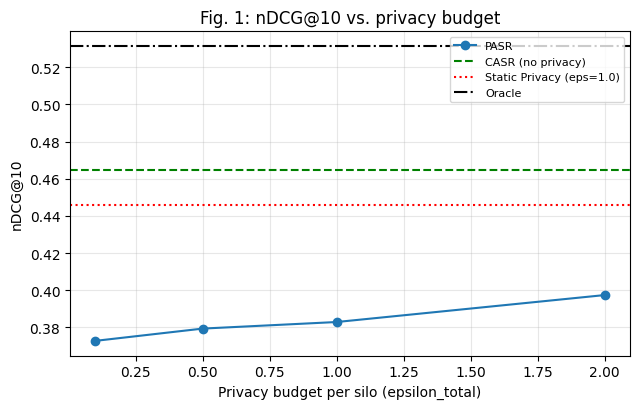

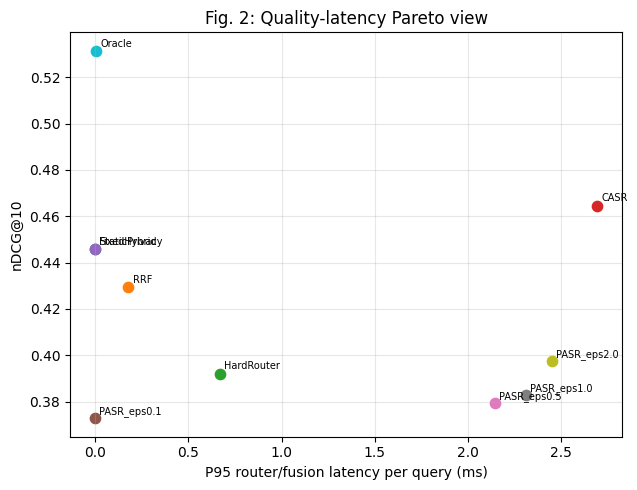

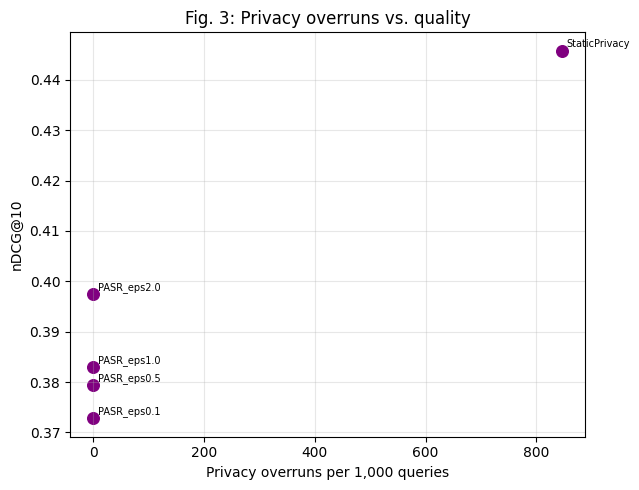

Saved 3 figures to /content/figures/


In [15]:
# CELL 15: Figures (300 DPI)
import matplotlib
import matplotlib.pyplot as plt
A = agg.set_index('experiment')
EPS_EXP = {0.1: 'E6_PASR_eps0.1', 0.5: 'E7_PASR_eps0.5', 1.0: 'E8_PASR_eps1.0', 2.0: 'E9_PASR_eps2.0'}

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(list(EPS_EXP), [A.loc[e, 'ndcg10_mean'] for e in EPS_EXP.values()], marker='o', label='PASR')
for name, label, style, col in [('E4_CASR', 'CASR (no privacy)', '--', 'green'),
                                ('E5_StaticPrivacy', 'Static Privacy (eps=1.0)', ':', 'red'),
                                ('E10_Oracle', 'Oracle', '-.', 'black')]:
    ax.axhline(A.loc[name, 'ndcg10_mean'], color=col, linestyle=style, label=label)
ax.set_xlabel('Privacy budget per silo (epsilon_total)'); ax.set_ylabel('nDCG@10')
ax.set_title('Fig. 1: nDCG@10 vs. privacy budget'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('/content/figures/fig1_ndcg_vs_epsilon.png', dpi=300); plt.show()

fig, ax = plt.subplots(figsize=(6.5, 5))
for name, r in A.iterrows():
    ax.scatter(r['lat_p95_mean'], r['ndcg10_mean'], s=55)
    ax.annotate(name.split('_', 1)[-1], (r['lat_p95_mean'], r['ndcg10_mean']), fontsize=7, xytext=(3, 3), textcoords='offset points')
ax.set_xlabel('P95 router/fusion latency per query (ms)'); ax.set_ylabel('nDCG@10')
ax.set_title('Fig. 2: Quality-latency Pareto view'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('/content/figures/fig2_pareto_frontier.png', dpi=300); plt.show()

fig, ax = plt.subplots(figsize=(6.5, 5))
sub = A.loc[['E5_StaticPrivacy'] + list(EPS_EXP.values())]
ax.scatter(sub['overruns_per_1k_mean'], sub['ndcg10_mean'], s=70, c='purple')
for name, r in sub.iterrows():
    ax.annotate(name.split('_', 1)[-1], (r['overruns_per_1k_mean'], r['ndcg10_mean']), fontsize=7, xytext=(3, 3), textcoords='offset points')
ax.set_xlabel('Privacy overruns per 1,000 queries'); ax.set_ylabel('nDCG@10')
ax.set_title('Fig. 3: Privacy overruns vs. quality'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('/content/figures/fig3_privacy_quality_tradeoff.png', dpi=300); plt.show()
print('Saved 3 figures to /content/figures/')

In [16]:
# CELL 16: Save results
agg.to_csv('/content/pasr_results.csv', index=False)
results_df.to_csv('/content/pasr_results_by_seed.csv', index=False)
per_silo_df.to_csv('/content/pasr_results_per_silo.csv', index=False)
export = dict(
    table1_main_results=table1.to_dict(orient='records'),
    table2_privacy_sweep=table2.to_dict(orient='records'),
    table3_per_silo=table3.reset_index().to_dict(orient='records'),
    aggregate=agg.to_dict(orient='records'),
    active_silos=active_silos,
    config=dict(eps_thr=EPS_THR, hybrid_alpha=HYBRID_ALPHA, tau=TAU, xgb_params=XGB_PARAMS, seeds=SEEDS,
                max_queries_per_silo=MAX_QUERIES_PER_SILO, dense_ok=DENSE_OK, rerank_ok=RERANK_OK))
with open('/content/pasr_results.json', 'w') as f:
    json.dump(export, f, indent=2, default=float)
print('Saved /content/pasr_results.csv, /content/pasr_results.json (+ by_seed, per_silo CSVs)')

Saved /content/pasr_results.csv, /content/pasr_results.json (+ by_seed, per_silo CSVs)


In [17]:
# CELL 17: Hypotheses summary
casr = A.loc['E4_CASR']; pasr = A.loc['E8_PASR_eps1.0']; stat = A.loc['E5_StaticPrivacy']
h1_gap = abs(casr['ndcg10_mean'] - pasr['ndcg10_mean'])           # 0-1 scale; 1.0 point = 0.01
h1 = 'VERIFIED' if h1_gap <= 0.01 else 'REJECTED'
red = 100 * (1 - pasr['overruns_per_1k_mean'] / stat['overruns_per_1k_mean']) if stat['overruns_per_1k_mean'] > 0 else float('nan')
h2 = 'VERIFIED' if red > 90 else 'REJECTED'
over = pasr['lat_p95_mean'] - casr['lat_p95_mean']
h3 = 'VERIFIED' if over < 100 else 'REJECTED'

print('=== EXPERIMENT COMPLETE ===')
print(f'H1 (PASR within 1.0 pt of CASR): [{h1}] - gap = {100*h1_gap:.2f} nDCG points (PASR eps=1.0 vs CASR)')
print(f'H2 (>90% overrun reduction):     [{h2}] - reduction = {red:.1f}%')
print(f'H3 (<100ms overhead):            [{h3}] - overhead = {over:.1f} ms (P95)')
print('Results saved to: /content/pasr_results.csv')
print('Figures saved to: /content/figures/')
print('\nCaveats: H2 holds by construction (PASR never touches an exhausted silo); the real cost shows in H1/Table II.')
print('Latency is router+fusion compute on precomputed rankings, not end-to-end retrieval.\n')

cols = ['experiment', 'ndcg10_mean', 'recall10_mean', 'mrr10_mean', 'overruns_per_1k_mean', 'lat_p95_mean']
hdr = '| Method | nDCG@10 | Recall@10 | MRR@10 | Overruns/1k | P95 ms | d nDCG vs PASR(eps=1) |\n|---|---|---|---|---|---|---|'
rows = [f"| {r.experiment} | {r.ndcg10_mean:.4f} | {r.recall10_mean:.4f} | {r.mrr10_mean:.4f} | "
        f"{r.overruns_per_1k_mean:.1f} | {r.lat_p95_mean:.2f} | {r.ndcg10_mean - pasr['ndcg10_mean']:+.4f} |"
        for r in agg[cols].itertuples()]
print(hdr + '\n' + '\n'.join(rows))

=== EXPERIMENT COMPLETE ===
H1 (PASR within 1.0 pt of CASR): [REJECTED] - gap = 8.16 nDCG points (PASR eps=1.0 vs CASR)
H2 (>90% overrun reduction):     [VERIFIED] - reduction = 100.0%
H3 (<100ms overhead):            [VERIFIED] - overhead = -0.4 ms (P95)
Results saved to: /content/pasr_results.csv
Figures saved to: /content/figures/

Caveats: H2 holds by construction (PASR never touches an exhausted silo); the real cost shows in H1/Table II.
Latency is router+fusion compute on precomputed rankings, not end-to-end retrieval.

| Method | nDCG@10 | Recall@10 | MRR@10 | Overruns/1k | P95 ms | d nDCG vs PASR(eps=1) |
|---|---|---|---|---|---|---|
| E1_FixedHybrid | 0.4458 | 0.5793 | 0.4585 | 0.0 | 0.00 | +0.0629 |
| E2_RRF | 0.4296 | 0.5614 | 0.4466 | 0.0 | 0.18 | +0.0467 |
| E3_HardRouter | 0.3921 | 0.5118 | 0.4131 | 0.0 | 0.67 | +0.0092 |
| E4_CASR | 0.4646 | 0.5934 | 0.4770 | 0.0 | 2.69 | +0.0816 |
| E5_StaticPrivacy | 0.4458 | 0.5793 | 0.4585 | 846.2 | 0.00 | +0.0629 |
| E6_PASR_eps0.1